# Clustering of road-segment types and driving styles

## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', 30)
sns.set_style('whitegrid')
RANDOM_STATE = 42

DATA = Path("./outputs/ved_enriched.parquet")
df = pd.read_parquet(DATA)
print(f"dataset shape {df.shape}")

dataset shape (17922869, 21)


## Definition of a "road segment"

A segment is a cell of the geographic grid (11×8 m).

For each cell we compute aggregated statistics of the behavior of the vehicles that passed through it:
- mean and std speed
- mean and std acceleration
- mean MAF
- mean RPM
- slope
- number of passages (for the filter)

In [2]:
df['lat_bin'] = df['Latitude_deg'].round(4)
df['lon_bin'] = df['Longitude_deg'].round(4)

agg = df.groupby(['lat_bin', 'lon_bin']).agg(
    n_passages=('MAF_g_per_sec', 'size'),
    speed_mean=('Vehicle_Speed_km_per_h', 'mean'),
    speed_std=('Vehicle_Speed_km_per_h', 'std'),
    accel_mean=('accel_kmh_s', 'mean'),
    accel_std=('accel_kmh_s', 'std'),
    accel_abs_mean=('accel_kmh_s', lambda s: s.abs().mean()),
    maf_mean=('MAF_g_per_sec', 'mean'),
    rpm_mean=('Engine_RPM_RPM', 'mean'),
    load_mean=('Absolute_Load_pct', 'mean'),
    slope_mean=('slope', 'mean'),
    elevation=('elevation_m', 'mean'),
).reset_index()

stops = df.groupby(['lat_bin', 'lon_bin'])['Vehicle_Speed_km_per_h'].apply(
    lambda s: (s < 2).mean()).reset_index(name='stop_fraction')
agg = agg.merge(stops, on=['lat_bin', 'lon_bin'])

print(f"Total cells: {len(agg):,}")
print(f"Range n_passages: [{agg['n_passages'].min()}, {agg['n_passages'].max()}]")
agg.head()

Total cells: 281,494
Range n_passages: [1, 3956]


,lat_bin,lon_bin,n_passages,speed_mean,speed_std,accel_mean,accel_std,accel_abs_mean,maf_mean,rpm_mean,load_mean,slope_mean,elevation,stop_fraction
0,42.220299,-83.797203,3,64.000000,2.000000,-2.888889,3.421068,2.888889,2.846667,1174.666626,14.509804,-0.017660,272.0,0.0
1,42.220299,-83.796204,4,63.500000,3.696846,2.424423,1.126853,2.424423,30.075001,1737.000000,65.882355,0.003965,275.0,0.0
2,42.220299,-83.767197,4,36.500000,1.290994,1.655844,2.263432,1.655844,7.810000,1160.000000,35.294117,-0.075000,258.0,0.0
3,42.220299,-83.760902,5,35.000000,1.870829,-3.363636,6.520787,3.363636,3.978000,1304.800049,12.549020,0.060000,294.0,0.0
4,42.220299,-83.760803,6,42.666668,1.366260,-0.694444,1.107633,0.694444,4.763333,1590.166626,15.882354,0.050000,294.0,0.0


### Cleanup of cells with few passages

necessary because the data could be skewed by a few "extraordinary" passages, such as someone driving very fast in an urban area, or a few passages on the highway all during congestion

Cells: 281,494 total -> 77,325 kept, 204,169 discarded (< 50 passages)


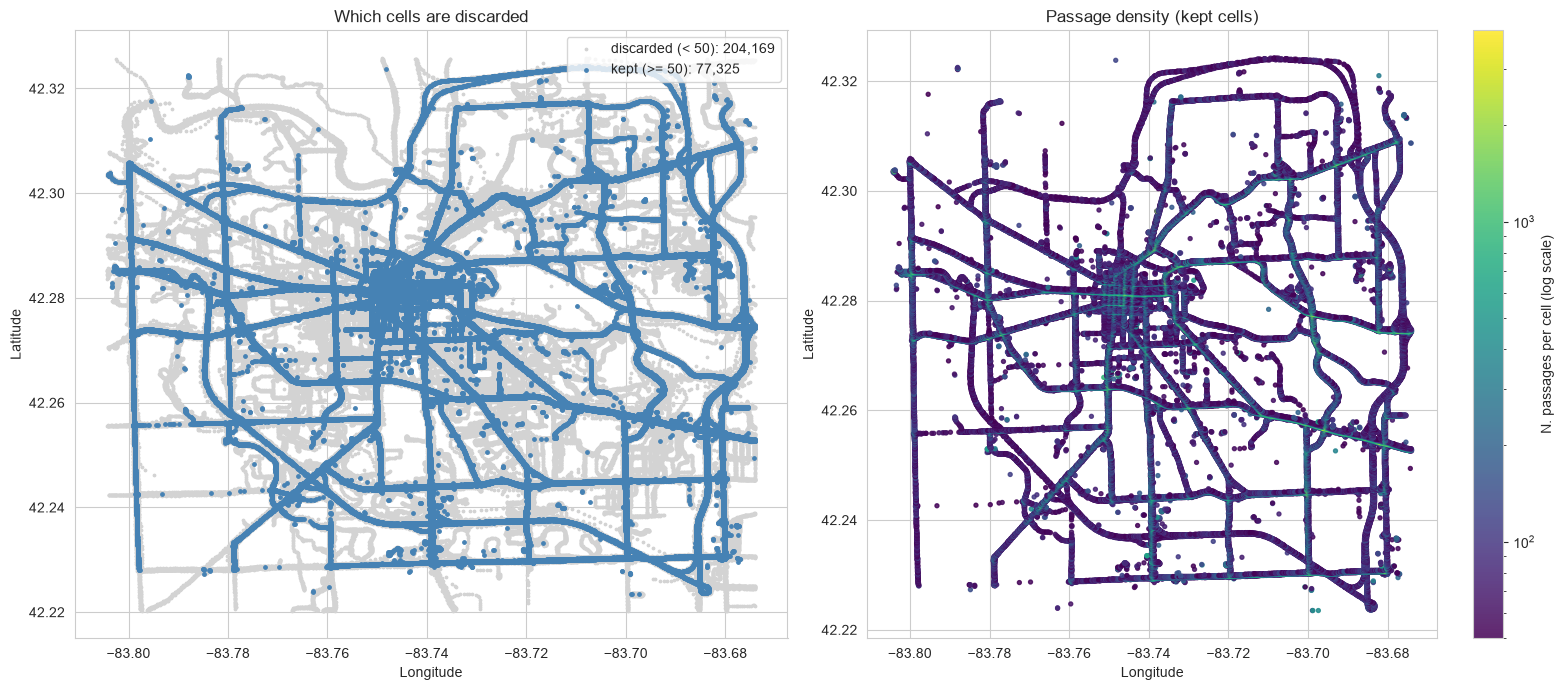

In [3]:
MIN_PASSAGES = 50
mask_keep = agg['n_passages'] >= MIN_PASSAGES
print(f"Cells: {len(agg):,} total -> {mask_keep.sum():,} kept, "
      f"{(~mask_keep).sum():,} discarded (< {MIN_PASSAGES} passages)")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.scatter(agg.loc[~mask_keep, 'lon_bin'], agg.loc[~mask_keep, 'lat_bin'],
           s=3, c='lightgray', label=f'discarded (< {MIN_PASSAGES}): {(~mask_keep).sum():,}')
ax.scatter(agg.loc[mask_keep, 'lon_bin'], agg.loc[mask_keep, 'lat_bin'],
           s=6, c='steelblue', label=f'kept (>= {MIN_PASSAGES}): {mask_keep.sum():,}')
ax.set_title('Which cells are discarded')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend(loc='upper right')

ax = axes[1]
kept = agg[mask_keep]
sc = ax.scatter(kept['lon_bin'], kept['lat_bin'], c=kept['n_passages'],
                cmap='viridis', s=8, alpha=0.85,
                norm=LogNorm(vmin=MIN_PASSAGES, vmax=kept['n_passages'].max()))
plt.colorbar(sc, ax=ax, label='N. passages per cell (log scale)')
ax.set_title('Passage density (kept cells)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

agg = agg[mask_keep].reset_index(drop=True)

## Feature selection for clustering

Chosen segment features: speed (mean/std), acceleration
(mean/std/abs), stop fraction (`stop_fraction`) and slope (`slope_mean`).

**Engine signals excluded** `maf_mean`, `rpm_mean`, `load_mean`: they are **redundant** with each other
(RPM/Load correlate with MAF 0.75 and 0.52) and they describe the *powertrain*, not the road.

We also exclude `n_passages` (meta-data), `elevation` (**absolute** altitude) and the coordinates (same reason).

In [4]:
FEATURES_CLUSTER = [
    'speed_mean', 'speed_std',
    'accel_mean', 'accel_std', 'accel_abs_mean',
    'slope_mean', 'stop_fraction'
]

X = agg[FEATURES_CLUSTER].copy()
X = X.dropna()
agg_clean = agg.loc[X.index].reset_index(drop=True)
X = X.reset_index(drop=True)
print(f"Final cells for clustering: {len(X):,}")
print(f"Features: {len(FEATURES_CLUSTER)}")

X.describe()

Final cells for clustering: 77,325
Features: 7


,speed_mean,speed_std,accel_mean,accel_std,accel_abs_mean,slope_mean,stop_fraction
count,77325.000000,77325.000000,77325.000000,77325.000000,77325.000000,77325.000000,77325.000000
mean,46.282219,14.307227,-0.146671,3.614341,1.773129,0.000124,0.077770
std,23.008968,7.086949,0.903107,0.937117,0.670067,0.018218,0.159084
min,0.000000,0.000000,-5.249651,0.000000,0.000000,-0.082192,0.000000
25%,29.344944,8.913104,-0.632350,2.974992,1.295158,-0.006121,0.000000
50%,46.254467,13.176139,-0.132034,3.613687,1.688191,0.000000,0.000000
75%,58.077103,18.334269,0.346891,4.244734,2.176733,0.006000,0.084112
max,121.697365,57.487869,4.166846,7.239012,5.437530,0.081307,1.000000


## Standardization

Look at the feature scales:
- `speed_mean`: 0–120 km/h
- `speed_std`: 0–55
- `accel_std`: 0–7
- `stop_fraction`: 0–1
- `slope_mean`: -0.08 to 0.08

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=FEATURES_CLUSTER)
print(X_scaled_df.describe().loc[['mean', 'std']].round(3))

      speed_mean  speed_std  accel_mean  accel_std  accel_abs_mean  \
mean         0.0        0.0        -0.0       -0.0            -0.0   
std          1.0        1.0         1.0        1.0             1.0   

      slope_mean  stop_fraction  
mean         0.0            0.0  
std          1.0            1.0  


## Elbow Method and Silhouette for the number of clusters

I try from 2 to 10 and see how the plots behave

  k=2: inertia=423786, silhouette=0.227
  k=3: inertia=353914, silhouette=0.250
  k=4: inertia=312365, silhouette=0.254
  k=5: inertia=271749, silhouette=0.246
  k=6: inertia=246614, silhouette=0.257
  k=7: inertia=223410, silhouette=0.245
  k=8: inertia=206727, silhouette=0.219
  k=9: inertia=192350, silhouette=0.226
  k=10: inertia=183357, silhouette=0.210


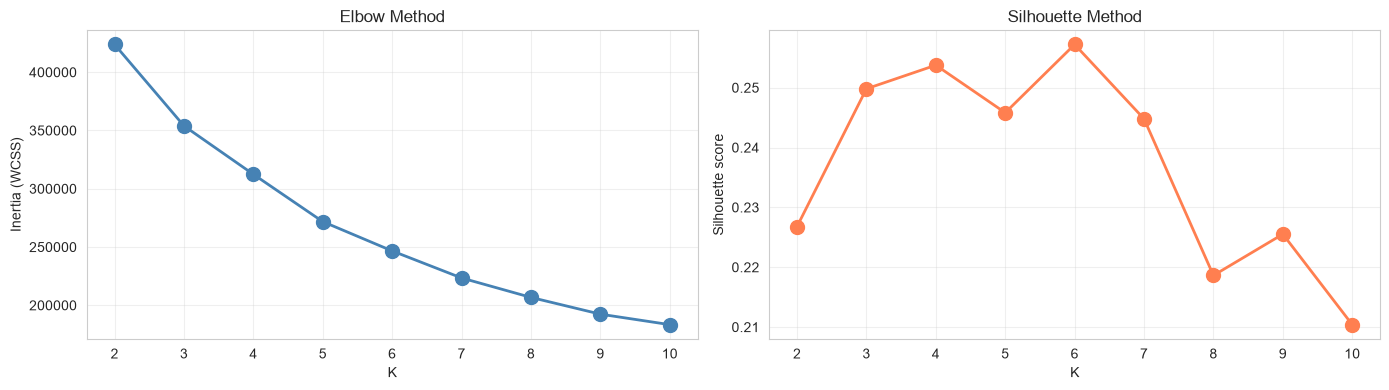

In [6]:
K_VALUES = list(range(2, 11))
inertias = []
silhouettes = []

if len(X_scaled) > 10000:
    sil_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), size=10000, replace=False)
else:
    sil_idx = np.arange(len(X_scaled))

for k in K_VALUES:
    km = KMeans(n_clusters=k, n_init=20, init='k-means++', random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled[sil_idx], labels[sil_idx])
    silhouettes.append(sil)
    print(f"  k={k}: inertia={km.inertia_:.0f}, silhouette={sil:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(K_VALUES, inertias, 'o-', color='steelblue', lw=2, markersize=10)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_VALUES, silhouettes, 'o-', color='coral', lw=2, markersize=10)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette Method')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Final choice
by eye the only feasible ones are 4 and 6; after two runs with the model the best is 4

In [7]:
K_FINAL=4

## K-Means
Below, K-Means with the chosen number of k and K-Means++ as initialization, because it picks initial centroids far apart from each other.

In [8]:
kmeans = KMeans(n_clusters=K_FINAL, n_init=50, init='k-means++', random_state=RANDOM_STATE)
labels = kmeans.fit_predict(X_scaled)
agg_clean['cluster'] = labels

print(agg_clean['cluster'].value_counts().sort_index())

cluster
0    31792
1     7951
2     5738
3    31844
Name: count, dtype: int64


## Assigning names to the clusters

looking at the clustering features plus MAF added as a descriptive column, we try to understand which road types each cluster belongs to

In [9]:
cluster_profile = agg_clean.groupby('cluster')[FEATURES_CLUSTER + ['n_passages']].mean().round(2)
cluster_profile['count'] = agg_clean['cluster'].value_counts().sort_index()

cluster_profile['maf_mean_descr'] = agg_clean.groupby('cluster')['maf_mean'].mean().round(2)

cluster_profile

,speed_mean,speed_std,accel_mean,accel_std,accel_abs_mean,slope_mean,stop_fraction,n_passages,count,maf_mean_descr
cluster,,,,,,,,,,
0,33.740002,15.530000,-0.30,4.46,2.38,0.0,0.08,242.33,31792,9.45
1,79.250000,27.139999,0.00,3.07,1.38,-0.0,0.03,122.76,7951,16.74
2,11.110000,13.280000,-0.08,2.95,1.14,-0.0,0.53,275.58,5738,6.31
3,56.910000,10.070000,-0.04,3.03,1.38,0.0,0.00,151.89,31844,10.23


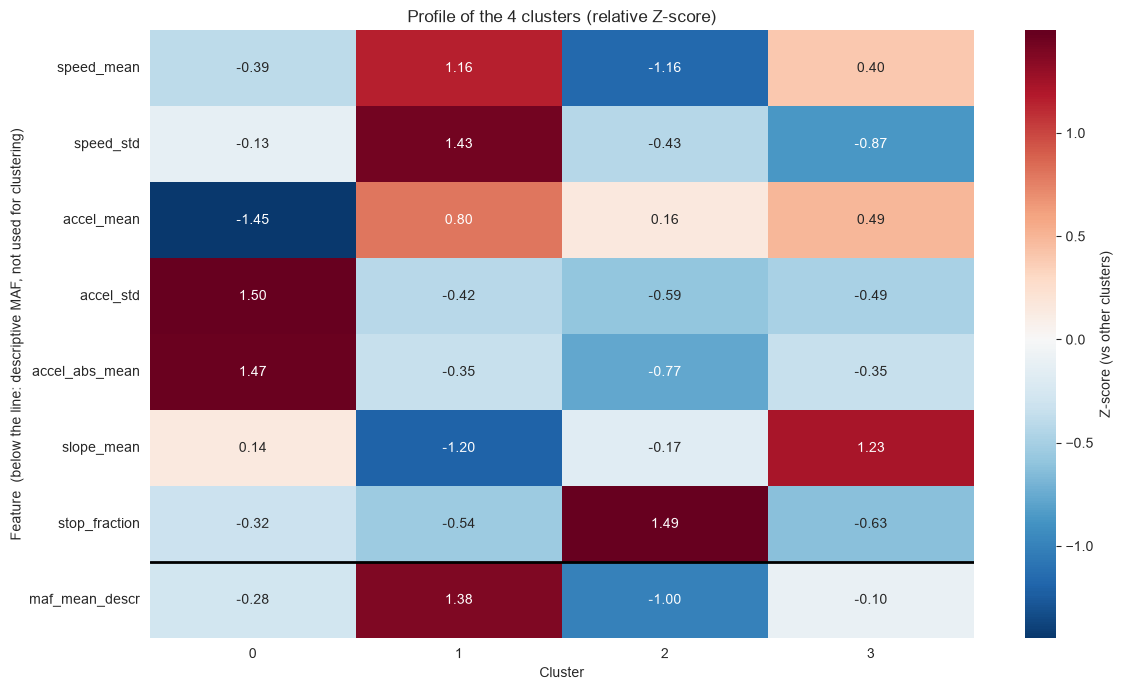

In [10]:
HEAT_COLS = FEATURES_CLUSTER + ['maf_mean']
profile_full = (agg_clean.groupby('cluster')[HEAT_COLS].mean()
                .rename(columns={'maf_mean': 'maf_mean_descr'}))
profile_norm = (profile_full - profile_full.mean()) / profile_full.std()

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(profile_norm.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Z-score (vs other clusters)'}, ax=ax)
ax.axhline(len(FEATURES_CLUSTER), color='black', lw=2)
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature  (below the line: descriptive MAF, not used for clustering)')
ax.set_title(f'Profile of the {K_FINAL} clusters (relative Z-score)')
plt.tight_layout()
plt.show()

### Cluster naming (AI method)

**WARNING: K-Means clusters have no fixed ordering** — on each re-run the same
patterns may get different IDs. That is why we name them **based on the profile values**, not on the
number: this way the name stays correct even if the IDs get shuffled.

**Naming logic** (cell below), in priority order:
- `stop_fraction > 0.50` → **Intersection/traffic light** (almost always stopped)
- `stop_fraction > 0.18` → **Urban stop-and-go** (many stops, but moving)
- `speed_mean ≥ 75` → **Highway/fast flow**
- `speed_mean ≥ 50` → **Free-flowing/fluid arterial** (fast but regular)
- moderate speed + few stops → distinguished by the **sign of the mean acceleration**:
  - `accel_mean > 0` → **Restarts/acceleration**
  - `accel_mean < 0` → **Approaching intersections/deceleration**

The thresholds are **interpretable** cutoffs (adjustable). Always check against the profile/heatmap above.

In [11]:
def name_cluster(row):
    sp, stop, am = row['speed_mean'], row['stop_fraction'], row['accel_mean']
    if stop > 0.50:
        return 'Intersection/traffic light'
    if stop > 0.18:
        return 'Urban environment'
    if sp >= 60:
        return 'Highway'
    if sp >= 50:
        return 'Free-flowing arterial road'
    if am > 0.4:
        return 'Restarts/accelerating segment'
    if am < -0.4:
        return 'Approaching intersections/deceleration'
    return 'Mixed urban'

cluster_profile['cluster_name'] = cluster_profile.apply(name_cluster, axis=1)
cluster_names = cluster_profile['cluster_name'].to_dict()

print("Naming (assigned from the profile values):")
for k, v in cluster_names.items():
    print(f"  Cluster {k}: {v:42s} "
          f"[speed={cluster_profile.loc[k, 'speed_mean']:.0f}, "
          f"stop={cluster_profile.loc[k, 'stop_fraction']:.2f}, "
          f"accel_mean={cluster_profile.loc[k, 'accel_mean']:+.2f}]")

agg_clean['cluster_name'] = agg_clean['cluster'].map(cluster_names)

Naming (assigned from the profile values):
  Cluster 0: Mixed urban                                [speed=34, stop=0.08, accel_mean=-0.30]
  Cluster 1: Highway                                    [speed=79, stop=0.03, accel_mean=+0.00]
  Cluster 2: Intersection/traffic light                 [speed=11, stop=0.53, accel_mean=-0.08]
  Cluster 3: Free-flowing arterial road                 [speed=57, stop=0.00, accel_mean=-0.04]


## 8. PCA visualization of the clusters

We project the cells (standardized clustering features) onto the first two principal components to *see* in 2D how separated the clusters are.

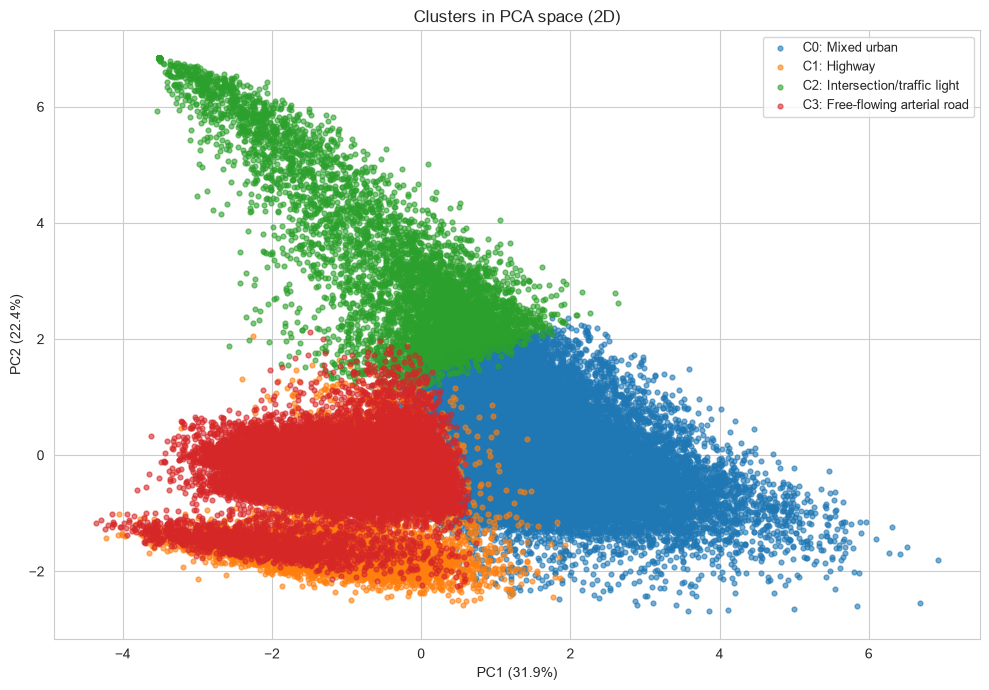

In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('tab10', K_FINAL)
for c in sorted(agg_clean['cluster'].unique()):
    mask = agg_clean['cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=12, alpha=0.6, color=palette[c],
               label=f'C{c}: {cluster_names[c]}')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Clusters in PCA space (2D)')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Geographic visualization — the map of Ann Arbor

**This is the "visual deliverable" section** of the project. We color the map of Ann Arbor with the clusters, obtaining a real geographic classification of the road-segment types.

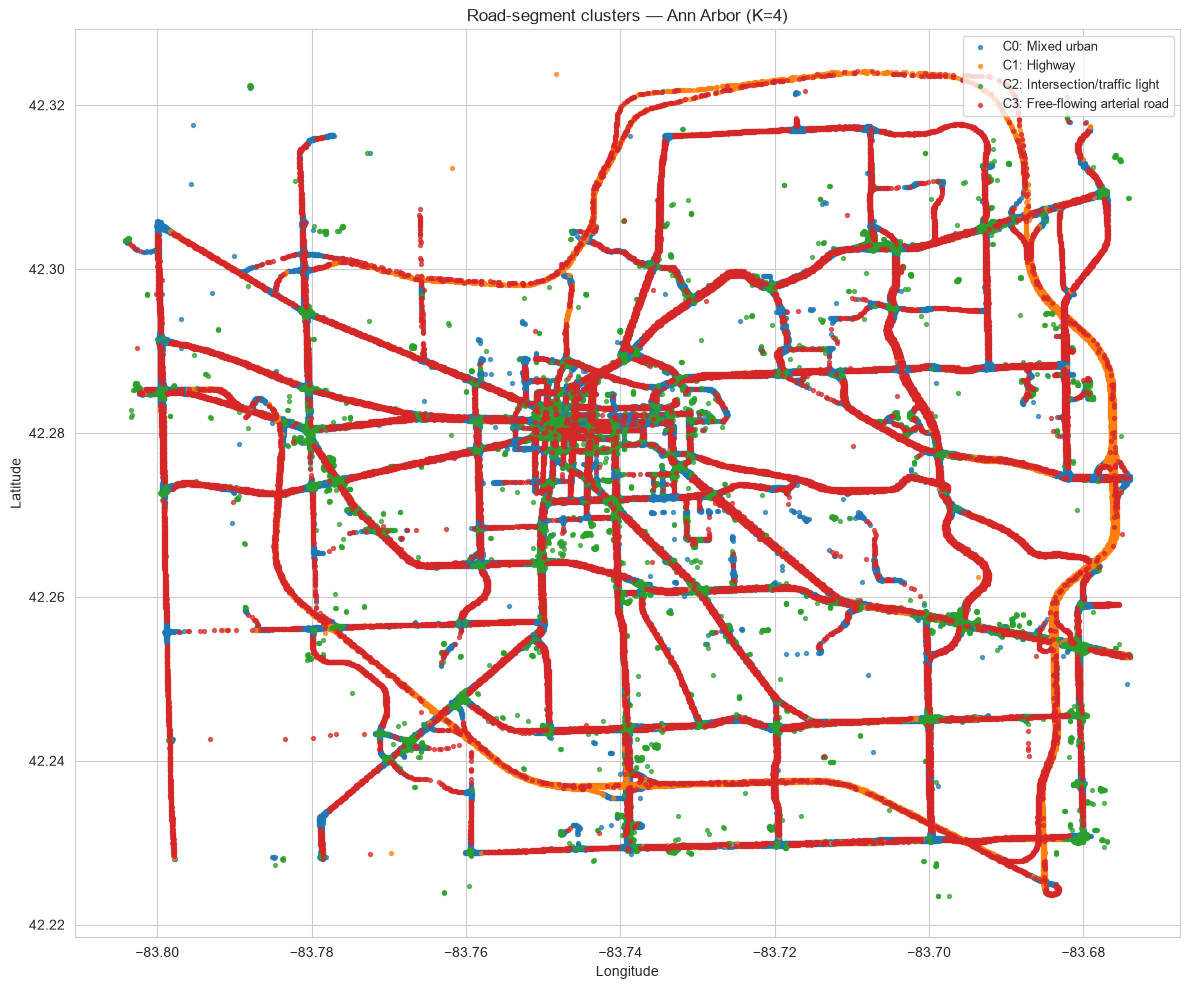

In [13]:
fig, ax = plt.subplots(figsize=(12, 10))
for c in sorted(agg_clean['cluster'].unique()):
    mask = agg_clean['cluster'] == c
    ax.scatter(agg_clean.loc[mask, 'lon_bin'], agg_clean.loc[mask, 'lat_bin'],
               s=8, alpha=0.7, color=palette[c],
               label=f'C{c}: {cluster_names[c]}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Road-segment clusters — Ann Arbor (K={K_FINAL})')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

In [14]:
try:
    import folium
    center = [agg_clean['lat_bin'].mean(), agg_clean['lon_bin'].mean()]
    m = folium.Map(location=center, zoom_start=13, tiles='cartodbpositron')

    palette_hex = [f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}'
                   for r, g, b in palette]

    plot_df = agg_clean.sample(n=min(10000, len(agg_clean)), random_state=RANDOM_STATE)

    for c in sorted(agg_clean['cluster'].unique()):
        fg = folium.FeatureGroup(name=f'C{c}: {cluster_names[c]}', show=True)
        sub = plot_df[plot_df['cluster'] == c]
        for _, row in sub.iterrows():
            folium.CircleMarker(
                location=[row['lat_bin'], row['lon_bin']],
                radius=3,
                color=palette_hex[c],
                fill=True,
                fill_opacity=0.7,
                popup=f"Cluster {c}: {cluster_names[c]}<br>"
                      f"Speed={row['speed_mean']:.1f} km/h<br>"
                      f"MAF={row['maf_mean']:.1f} g/s<br>"
                      f"Stop frac={row['stop_fraction']:.2f}"
            ).add_to(fg)
        fg.add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)

    legend_html = ('<div style="position: fixed; bottom: 30px; left: 30px; width: 250px; '
                   'background: white; border:2px solid grey; padding: 10px; z-index: 1000;">'
                   '<b>Cluster colors</b><br>')
    for c, name in cluster_names.items():
        legend_html += (f'<i style="background:{palette_hex[c]}; width:12px; height:12px; '
                        f'display:inline-block;"></i> C{c}: {name}<br>')
    legend_html += '</div>'
    m.get_root().html.add_child(folium.Element(legend_html))

    OUT_MAP = Path('./outputs/cluster_map.html')
    m.save(str(OUT_MAP))
    print(f"✓ Interactive map saved: {OUT_MAP}")
    print("  Open the HTML file: use the panel in the top right to show/hide the clusters.")
except ImportError:
    print("folium not installed. Install with: pip install folium")
    print("For now the static map saved above is fine.")

✓ Interactive map saved: outputs\cluster_map.html
  Open the HTML file: use the panel in the top right to show/hide the clusters.


## Saving the results

In [15]:
cluster_profile.to_csv('./outputs/cluster_profile.csv')
print("\u2713 Saved:")
print("  outputs/cluster_profile.csv  (profile + name of each cluster = how I clustered)")
print("  outputs/cluster_map.html     (interactive map, saved above)")

✓ Saved:
  outputs/cluster_profile.csv  (profile + name of each cluster = how I clustered)
  outputs/cluster_map.html     (interactive map, saved above)


---
# Part B — Driving styles

So far (Part A) we clustered **road segments**. Now we change the unit: the **driver**
(`VehId`). We characterize the **driving style** from **kinematics** alone (speed, accelerations,
stops) — no MAF/RPM. This is essential: kinematics is **valid and comparable across all
three powertrains** (ICE/HEV/PHEV), whereas consumption (MAF) is not (for hybrids the engine turns off).

We also observe the **composition by engine type** (`EngineType`) of the style groups. In this
version we stop at the style profile; the statistical test style × powertrain and the energy
comparison between engines remain a possible extension.

## B.1 Kinematic profile per driver

We aggregate the telemetry per `VehId`: mean/variability/cruising speed (p85), mean
and hard acceleration, hard braking, stop fraction. No MAF/RPM -> powertrain-agnostic features.

In [16]:
g = df.groupby('VehId')
driver = g.agg(
    EngineType=('EngineType', 'first'),
    n=('VehId', 'size'),
    speed_mean=('Vehicle_Speed_km_per_h', 'mean'),
    speed_std=('Vehicle_Speed_km_per_h', 'std'),
    speed_p85=('Vehicle_Speed_km_per_h', lambda s: s.quantile(0.85)),
    accel_abs_mean=('accel_kmh_s', lambda s: s.abs().mean()),
    accel_std=('accel_kmh_s', 'std'),
    frac_hard_accel=('accel_kmh_s', lambda s: (s > 6).mean()),
    frac_hard_decel=('accel_kmh_s', lambda s: (s < -6).mean()),
    stop_fraction=('Vehicle_Speed_km_per_h', lambda s: (s < 2).mean()),
).reset_index()

driver = driver[driver['n'] >= 2000].reset_index(drop=True)
STYLE_FEATURES = ['speed_mean','speed_std','speed_p85','accel_abs_mean','accel_std',
                  'frac_hard_accel','frac_hard_decel','stop_fraction']
print(f"Drivers: {len(driver)} | by EngineType:")
print(driver['EngineType'].value_counts().to_string())
driver[STYLE_FEATURES].describe().round(3)

Drivers: 278 | by EngineType:
EngineType
ICE     177
HEV      89
PHEV     12


,speed_mean,speed_std,speed_p85,accel_abs_mean,accel_std,frac_hard_accel,frac_hard_decel,stop_fraction
count,278.000,278.000,278.000,278.000,278.000,278.000,278.000,278.000
mean,41.036,25.798,66.956,1.828,3.918,0.057,0.056,0.114
std,7.869,4.614,11.911,0.243,0.286,0.009,0.008,0.082
min,8.020,14.447,23.000,0.817,2.737,0.026,0.026,0.000
25%,35.747,22.415,60.250,1.698,3.762,0.052,0.051,0.037
50%,40.423,25.262,64.000,1.841,3.950,0.058,0.055,0.124
75%,45.642,28.474,69.060,2.006,4.118,0.063,0.061,0.160
max,69.748,42.003,118.000,2.403,4.663,0.081,0.084,0.667


## B.2 Standardization and choice of K (elbow + silhouette)

  k=2: inertia=1552, silhouette=0.287
  k=3: inertia=1218, silhouette=0.290
  k=4: inertia=1050, silhouette=0.228
  k=5: inertia=912, silhouette=0.246
  k=6: inertia=807, silhouette=0.250
  k=7: inertia=714, silhouette=0.256
  k=8: inertia=646, silhouette=0.262


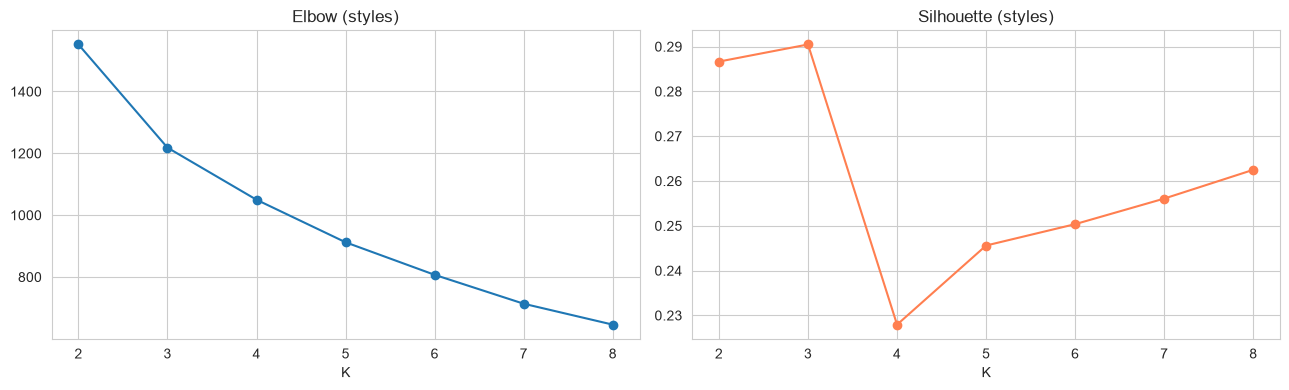

Chosen K (styles): 3 (change by hand if you prefer the elbow)


In [17]:
Xs = StandardScaler().fit_transform(driver[STYLE_FEATURES])
Ks = list(range(2, 9)); inertias=[]; sils=[]
for k in Ks:
    km = KMeans(n_clusters=k, n_init=20, init='k-means++', random_state=RANDOM_STATE).fit(Xs)
    inertias.append(km.inertia_); sils.append(silhouette_score(Xs, km.labels_))
    print(f"  k={k}: inertia={km.inertia_:.0f}, silhouette={sils[-1]:.3f}")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(Ks, inertias, 'o-'); axes[0].set_title('Elbow (styles)'); axes[0].set_xlabel('K')
axes[1].plot(Ks, sils, 'o-', color='coral'); axes[1].set_title('Silhouette (styles)'); axes[1].set_xlabel('K')
plt.tight_layout(); plt.show()
K_STYLE = Ks[int(np.argmax([s if 3 <= k <= 6 else -1 for k, s in zip(Ks, sils)]))]
print("Chosen K (styles):", K_STYLE, "(change by hand if you prefer the elbow)")

## B.3 K-Means, profile and naming of the styles

Heuristic naming to be reviewed by looking at the heatmap (as for the road clusters).

       speed_mean  speed_std  speed_p85  accel_abs_mean  accel_std  frac_hard_accel  frac_hard_decel  stop_fraction    n
style                                                                                                                   
0       36.113998  24.745001  60.835999           1.591      3.658            0.049            0.049          0.159   91
1       40.201000  24.080999  63.639000           1.996      4.121            0.063            0.061          0.095  131
2       50.990002  31.524000  84.662003           1.820      3.865            0.056            0.054          0.085   56


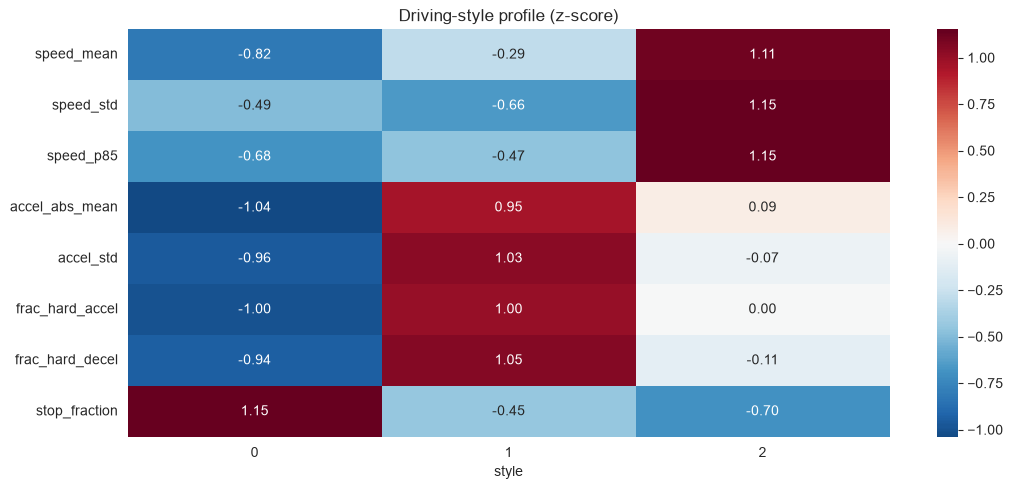


Proposed naming: {0: 'Urban stop-and-go', 1: 'Aggressive', 2: 'Cruising/extra-urban'}


In [18]:
km = KMeans(n_clusters=K_STYLE, n_init=50, init='k-means++', random_state=RANDOM_STATE)
driver['style'] = km.fit_predict(Xs)
prof = driver.groupby('style')[STYLE_FEATURES].mean().round(3)
prof['n'] = driver['style'].value_counts().sort_index()
print(prof.to_string())

prof_z = (prof[STYLE_FEATURES] - prof[STYLE_FEATURES].mean()) / prof[STYLE_FEATURES].std()
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(prof_z.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Driving-style profile (z-score)'); plt.tight_layout(); plt.show()

def name_style(r):
    if r['stop_fraction'] > prof['stop_fraction'].quantile(0.66): return 'Urban stop-and-go'
    if r['frac_hard_accel'] + r['frac_hard_decel'] > (prof['frac_hard_accel']+prof['frac_hard_decel']).quantile(0.66): return 'Aggressive'
    if r['speed_p85'] > prof['speed_p85'].quantile(0.66): return 'Cruising/extra-urban'
    return 'Moderate'
style_names = {i: name_style(prof.loc[i]) for i in prof.index}
driver['style_name'] = driver['style'].map(style_names)
print("\nProposed naming:", style_names)

## B.4 PCA of the styles

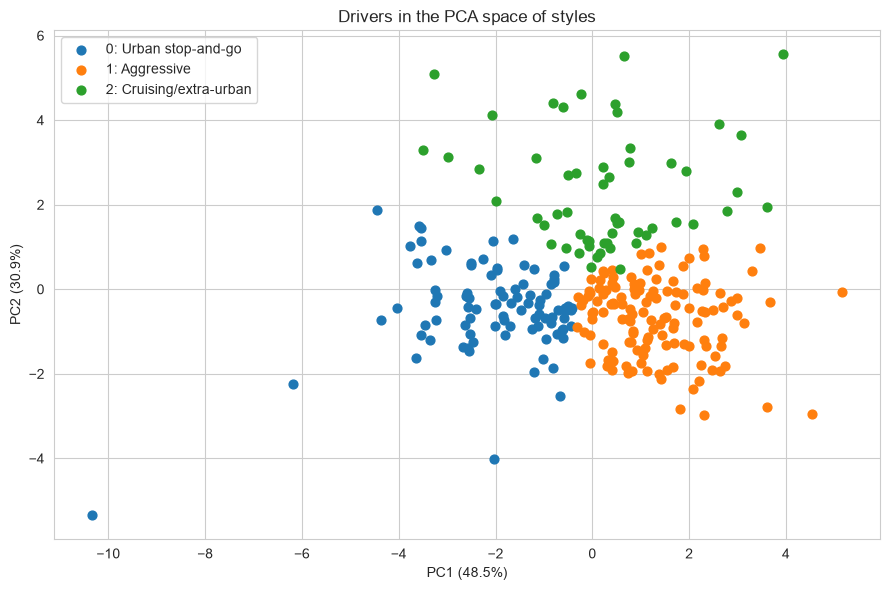

In [19]:
pca_s = PCA(n_components=2, random_state=RANDOM_STATE)
Zs = pca_s.fit_transform(Xs)
fig, ax = plt.subplots(figsize=(9, 6))
pal = sns.color_palette('tab10', K_STYLE)
for c in sorted(driver['style'].unique()):
    m = driver['style'] == c
    ax.scatter(Zs[m, 0], Zs[m, 1], s=40, color=pal[c], label=f"{c}: {style_names[c]}")
ax.set_xlabel(f'PC1 ({pca_s.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_s.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Drivers in the PCA space of styles'); ax.legend(); plt.tight_layout(); plt.show()